In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [2]:
!ls ../data/processed/

data_clean.csv


In [3]:
FILE = '../data/processed/data_clean.csv'

df = pd.read_csv(FILE)

print(df.shape)
df.head()

(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.500,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.750,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650,1


# ETL

In [4]:
categorical_cols = df.select_dtypes(include='str').columns.tolist()
numerical_cols = df.select_dtypes(include='number').columns

# EDA

In [5]:
df_model = df.copy()

df_model = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   int64  
 6   Partner_Yes                            7043 non-null   int64  
 7   Dependents_Yes                         7043 non-null   int64  
 8   PhoneService_Yes                       7043 non-null   int64  
 9   MultipleLines_No phone service         7043 non-null   int64  
 10  MultipleLines_Yes                      7043 non-null   int64  
 11  InternetService

In [6]:
df_model['No_internet_service'] = (
    (df_model['OnlineSecurity_No internet service']) |
    (df_model['OnlineBackup_No internet service']) |
    (df_model['DeviceProtection_No internet service']) |
    (df_model['TechSupport_No internet service']) |
    (df_model['StreamingTV_No internet service']) |
    (df_model['StreamingMovies_No internet service'])
).astype(int)

drop_cols = [col for col in df_model.columns if 'No internet service' in col]
df_model = df_model.drop(columns=drop_cols)

## Correlation

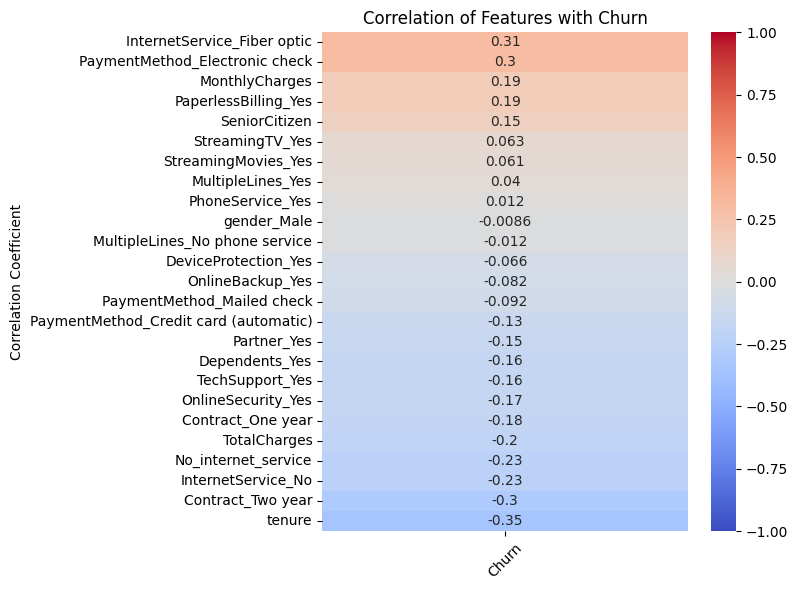

In [7]:
corr_matrix = df_model.corr(numeric_only=True)

churn_corr = corr_matrix['Churn'].sort_values(ascending=False).drop('Churn')

plt.figure(figsize=(8, 6))
sns.heatmap(churn_corr.to_frame(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of Features with Churn")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()